# Machine Learning Modeling

This notebook builds a machine learning pipeline to predict 
the probability of loan default on LendingClub data, 
using the cleaned dataset produced in `01_eda_cleaning.ipynb`.

The pipeline has two goals. The first is to predict which 
borrowers are most likely to default, using only information 
available at the time the loan was issued. The second is to 
use those predicted probabilities to assess whether 
LendingClub's interest rates reflect borrower risk — 
or whether systematic mispricing exists.

In [52]:
import pandas as pd

df = pd.read_csv("cleaned_data.csv")

df.head(10)

,loan_amnt,term (months),int_rate,grade,sub_grade,installment,emp_title,emp_length (years),home_ownership,annual_inc,...,loan_status,total_pymnt,total_rec_prncp,recoveries,collection_recovery_fee,fico_avg,default,loan_to_income_ratio (%),fico_avg_bin,loan_bin
0,3600.0,36,13.99,C,C4,123.03,Leadman,10.0,Mortgage,55000.0,...,Fully Paid,4421.72,3600.0,0.0,0.0,677.0,0,6.55,"(661.814, 680.55]","(966.0, 4400.0]"
1,24700.0,36,11.99,C,C1,820.28,Engineer,10.0,Mortgage,65000.0,...,Fully Paid,25679.66,24700.0,0.0,0.0,717.0,0,38.00,"(699.1, 717.65]","(21400.0, 24800.0]"
2,20000.0,60,10.78,B,B4,432.66,Truck driver,10.0,Mortgage,63000.0,...,Fully Paid,22705.92,20000.0,0.0,0.0,697.0,0,31.75,"(680.55, 699.1]","(18000.0, 21400.0]"
3,10400.0,60,22.45,F,F1,289.91,Contract specialist,3.0,Mortgage,104433.0,...,Fully Paid,11740.50,10400.0,0.0,0.0,697.0,0,9.96,"(680.55, 699.1]","(7800.0, 11200.0]"
4,11950.0,36,13.44,C,C3,405.18,Veterinary tecnician,4.0,Rent,34000.0,...,Fully Paid,13708.95,11950.0,0.0,0.0,692.0,0,35.15,"(680.55, 699.1]","(11200.0, 14600.0]"
5,20000.0,36,9.17,B,B2,637.58,Vice president of recruiting operations,10.0,Mortgage,180000.0,...,Fully Paid,21393.80,20000.0,0.0,0.0,682.0,0,11.11,"(680.55, 699.1]","(18000.0, 21400.0]"
6,20000.0,36,8.49,B,B1,631.26,Road driver,10.0,Mortgage,85000.0,...,Fully Paid,21538.51,20000.0,0.0,0.0,707.0,0,23.53,"(699.1, 717.65]","(18000.0, 21400.0]"
7,10000.0,36,6.49,A,A2,306.45,Service manager,6.0,Rent,85000.0,...,Fully Paid,10998.97,10000.0,0.0,0.0,687.0,0,11.76,"(680.55, 699.1]","(7800.0, 11200.0]"
8,8000.0,36,11.48,B,B5,263.74,Vendor liaison,10.0,Mortgage,42000.0,...,Fully Paid,8939.58,8000.0,0.0,0.0,702.0,0,19.05,"(699.1, 717.65]","(7800.0, 11200.0]"
9,1400.0,36,12.88,C,C2,47.10,Logistics manager,3.0,Mortgage,64000.0,...,Fully Paid,1575.16,1400.0,0.0,0.0,702.0,0,2.19,"(699.1, 717.65]","(966.0, 4400.0]"


In [53]:
from sklearn.model_selection import train_test_split

In [56]:
df.dtypes

loan_amnt                   float64
term (months)                 int64
int_rate                    float64
grade                        object
sub_grade                    object
installment                 float64
emp_title                    object
emp_length (years)          float64
home_ownership               object
annual_inc                  float64
verification_status          object
purpose                      object
dti                         float64
fico_range_low              float64
fico_range_high             float64
open_acc                      int64
revol_bal                   float64
revol_util                  float64
delinq_2yrs                   int64
total_acc                     int64
pub_rec                       int64
loan_status                  object
total_pymnt                 float64
total_rec_prncp             float64
recoveries                  float64
collection_recovery_fee     float64
fico_avg                    float64
default                     

In [58]:
df.isnull().sum().sort_values(ascending = False)

loan_bin                    33
revol_bal                    0
fico_avg_bin                 0
loan_to_income_ratio (%)     0
default                      0
fico_avg                     0
collection_recovery_fee      0
recoveries                   0
total_rec_prncp              0
total_pymnt                  0
loan_status                  0
pub_rec                      0
total_acc                    0
delinq_2yrs                  0
revol_util                   0
loan_amnt                    0
term (months)                0
fico_range_high              0
fico_range_low               0
dti                          0
purpose                      0
verification_status          0
annual_inc                   0
home_ownership               0
emp_length (years)           0
emp_title                    0
installment                  0
sub_grade                    0
grade                        0
int_rate                     0
open_acc                     0
dtype: int64

## 01. Models
Two models were trained on 35,204 loans and evaluated 
on a held-out test set of 8,801 loans.

**Logistic Regression** was used as the baseline. 
It is a simple, interpretable model that draws a linear 
boundary between defaulters and non-defaulters. 
It achieved an accuracy of 80.25% and a ROC-AUC of 0.7288.

**XGBoost** was used as the primary model. 
It improves on logistic regression by capturing 
non-linear relationships and interactions between features 
that a linear model cannot detect. 
It achieved an accuracy of 80.32% and a ROC-AUC of 0.7315.

In [61]:
from sklearn.preprocessing import OneHotEncoder


In [63]:
leakage_columns = ['total_pymnt', 'total_rec_prncp', 'recoveries', 
                'collection_recovery_fee']
categorical_columns = ["grade", "sub_grade", "home_ownership", "verification_status", "purpose"]
drop_col = ['fico_avg_bin', 'default', 'loan_bin', 'emp_title', 'loan_status', 'fico_range_low', 'fico_range_high'] + leakage_columns
X = df.drop(drop_col, axis = 1)
y = df["default"] # our target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=5)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)



(35204, 20) (8801, 20) (35204,) (8801,)


In [65]:
import numpy as np

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

#making sure that all NAs have been filled wit the median
numeric_cols = X_train.select_dtypes(include="number").columns
X_train[numeric_cols] = X_train[numeric_cols].fillna(X_train[numeric_cols].median())
X_test[numeric_cols] = X_test[numeric_cols].fillna(X_train[numeric_cols].median())

# Fill categorical NaNs with 'unknown'
cat_cols = X_train.select_dtypes(include='object').columns
X_train[cat_cols] = X_train[cat_cols].fillna('unknown')
X_test[cat_cols] = X_test[cat_cols].fillna('unknown')

In [67]:
## encoding categorical columns

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
x_train_encoded = encoder.fit_transform(X_train[cat_cols])
x_test_encoded = encoder.transform(X_test[cat_cols])


In [69]:
#combining back categorical and numeric columns
numeric_train = X_train[numeric_cols].values
numeric_test = X_test[numeric_cols].values



X_train_final = np.hstack((x_train_encoded, numeric_train))
X_test_final = np.hstack((x_test_encoded, numeric_test))

In [71]:
from sklearn.linear_model import LogisticRegression
logit = LogisticRegression(penalty='l2', tol=0.0001, C=1.0, max_iter=1000)
# Fit the logistic regression model to the train data
logit.fit(X_train_final, y_train)
y_pred_logit = logit.predict(X_test_final)
y_proba_logit = logit.predict_proba(X_test_final)
y_proba_logit_pos = y_proba_logit[:, 1]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [72]:
print(y_pred_logit)

[0 0 0 ... 0 0 0]


In [73]:
print(y_proba_logit)

[[0.66553491 0.33446509]
 [0.75348096 0.24651904]
 [0.8976241  0.1023759 ]
 ...
 [0.9086589  0.0913411 ]
 [0.8776923  0.1223077 ]
 [0.92160159 0.07839841]]


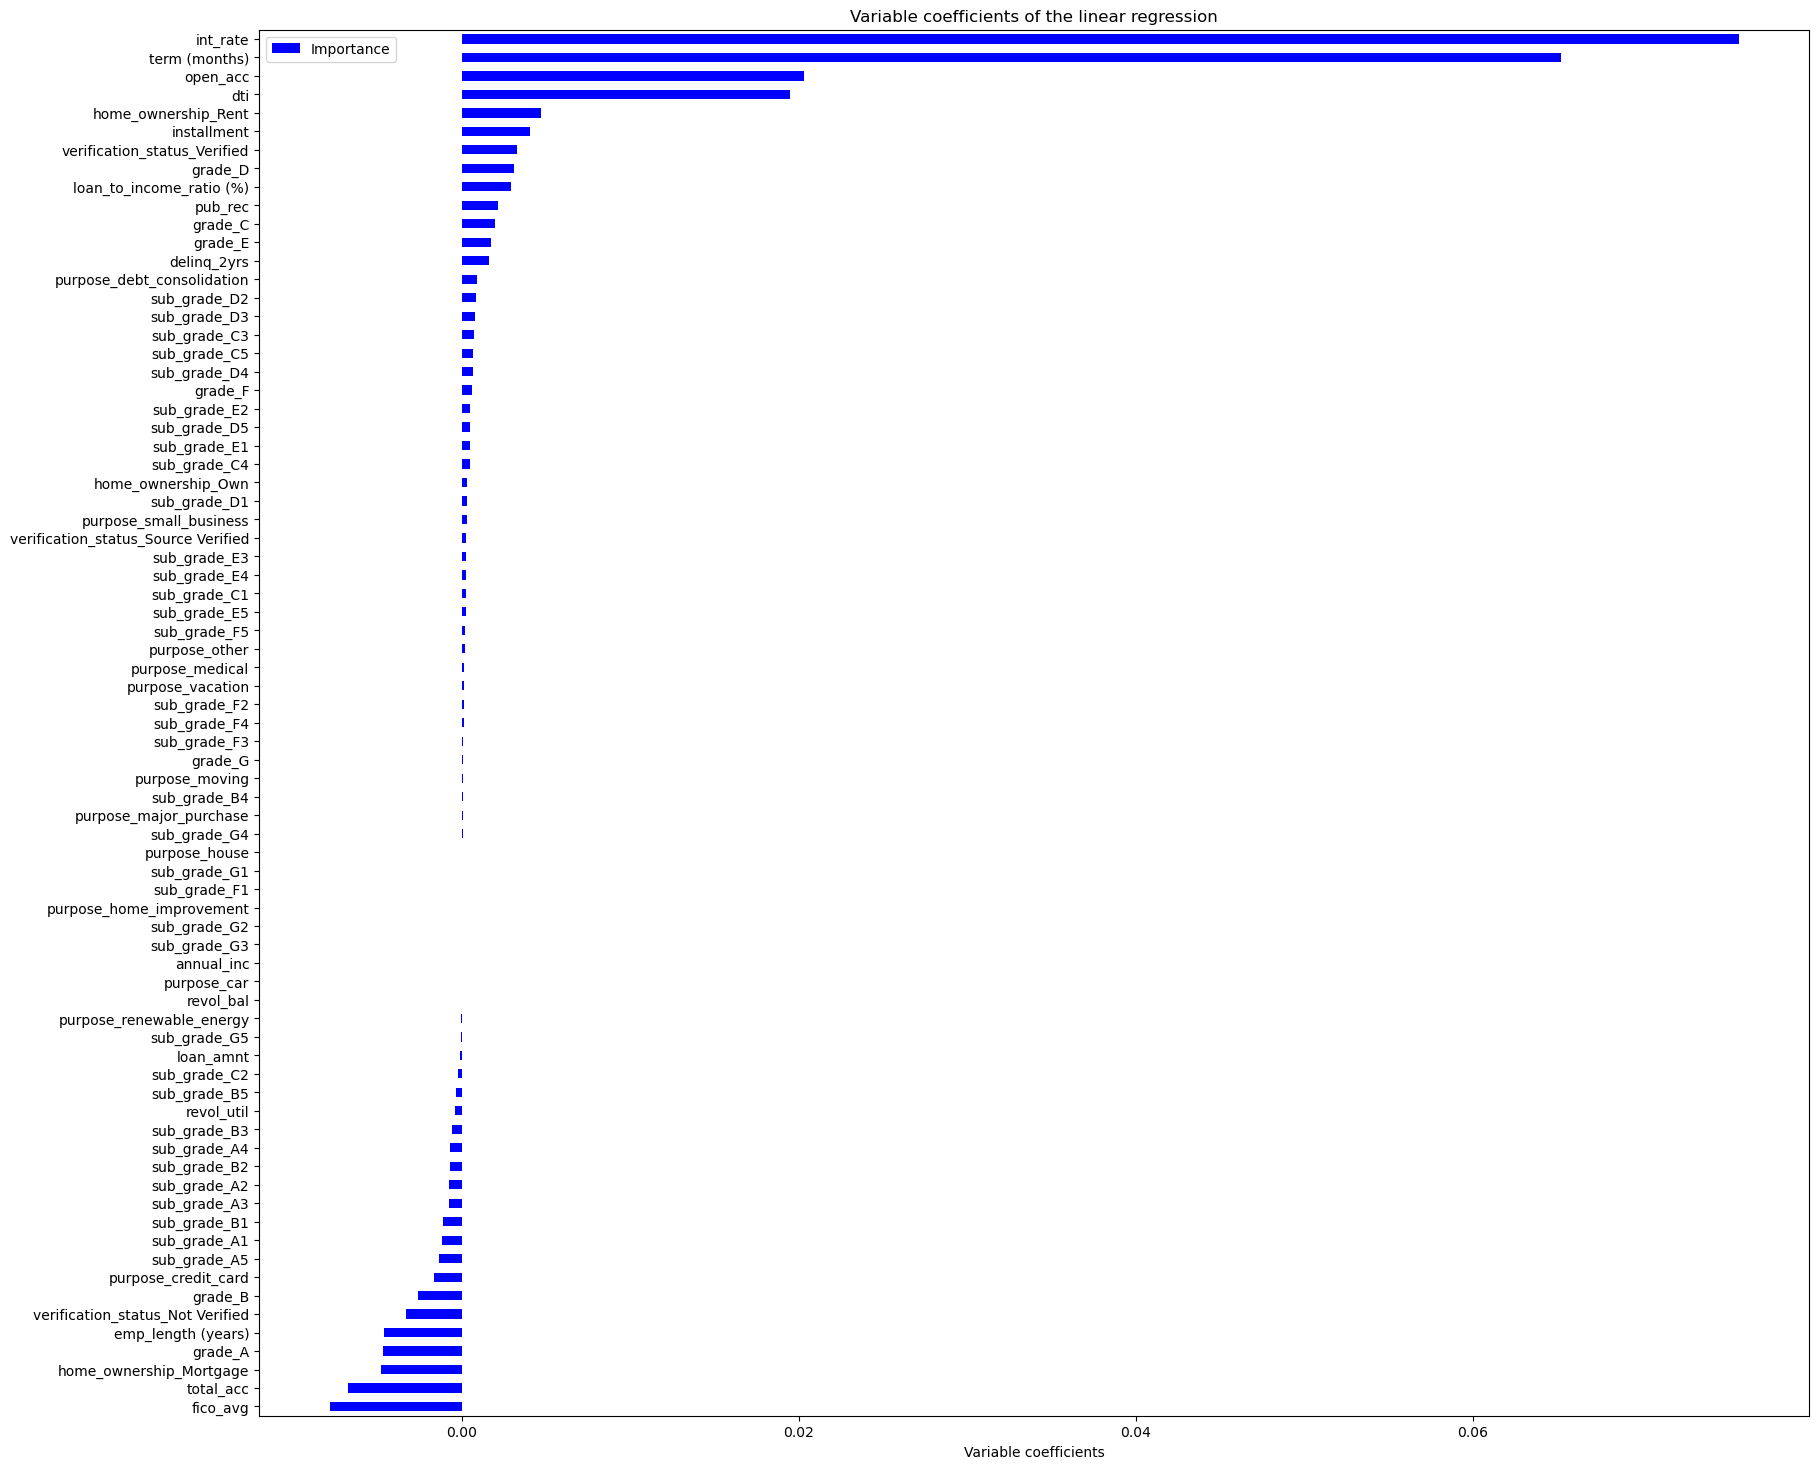

In [74]:
import matplotlib.pyplot as plt


feature_names = list(encoder.get_feature_names_out(cat_cols)) + list(numeric_cols)
coefs = pd.DataFrame(logit.coef_.flatten(), #pandas wants a 1D array, not 2D
                         index=feature_names, # # ← you told pandas: “use these as row labels”
                         columns = ['Importance']) ## ← and this as the column label
coefs = coefs.sort_values(by='Importance', ascending=True)
coefs.plot(kind='barh', figsize=(20,18), color = 'blue')
plt.xlabel('Variable coefficients')
plt.title('Variable coefficients of the linear regression')
plt.show()

## 02. Model Performance
Accuracy alone is not the right metric here — 
a model that predicted "repaid" for every single loan 
would achieve roughly 80% accuracy simply because 
80% of loans in the dataset did not default. 
ROC-AUC is the meaningful measure: it reflects how well 
the model ranks defaulters above non-defaulters 
regardless of the threshold chosen.

In [76]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

acc_logit = accuracy_score(y_test, y_pred_logit ) * 100
roc_auc_logit = roc_auc_score(y_test,y_proba_logit_pos) 

print(f"Accuracy : {acc_logit:.2f}%")  # expect ~65-72%
print(f"ROC-AUC  : {roc_auc_logit:.4f}")       # expect ~0.68-0.72
print(classification_report(y_test, y_pred_logit))


Accuracy : 80.25%
ROC-AUC  : 0.7288
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      7002
           1       0.56      0.16      0.25      1799

    accuracy                           0.80      8801
   macro avg       0.69      0.56      0.57      8801
weighted avg       0.76      0.80      0.76      8801



In [77]:

from xgboost import XGBClassifier 

params = {
    'objective':'binary:logistic',
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':300,
    'alpha':10,
    'eval_metric': 'auc',
    'random_state': 42
}

xgb_model = XGBClassifier(**params)

xgb_model.fit(X_train_final, y_train)

y_pred_xgb = xgb_model.predict(X_test_final)
y_proba_xgb= xgb_model.predict_proba(X_test_final)

In [78]:
acc_xgb = accuracy_score(y_test, y_pred_xgb) * 100
roc_auc_xgb = roc_auc_score(y_test,y_proba_xgb[:, 1]) 

print(f"Accuracy : {acc_xgb:.2f}%")  # expect ~65-72%
print(f"ROC-AUC  : {roc_auc_xgb:.4f}")       # expect ~0.68-0.72
print(classification_report(y_test, y_pred_xgb))


Accuracy : 80.32%
ROC-AUC  : 0.7315
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      7002
           1       0.56      0.16      0.25      1799

    accuracy                           0.80      8801
   macro avg       0.69      0.57      0.57      8801
weighted avg       0.77      0.80      0.76      8801



In [79]:
#stacking + coefficient graph

### 03. Risk vs Loan Pricing Analysis
Having built a model that predicts default probability 
with an AUC of 0.73, those predicted risk scores are now 
used to answer the central question of this project: 
**are LendingClub's interest rates actually reflecting 
the risk they are taking on?**

Every loan in the full dataset is scored with its 
predicted default probability and grouped into ten 
equal-size deciles — decile 1 contains the 10% of 
loans the model considers safest, decile 10 the 
10% it considers riskiest. The average interest rate 
and average predicted risk are then calculated 
for each decile.

The line chart plots predicted default risk on the 
x-axis against average interest rate on the y-axis. 
Each point represents one decile. If pricing is 
correct, the line should rise steeply and consistently 
— higher risk should always mean a meaningfully 
higher rate. A flattening of the line at the 
high-risk end would indicate that the riskiest 
borrowers are not being charged proportionally more, 
meaning the lender is absorbing uncompensated risk.

The heatmap then breaks this down further by 
loan grade and risk decile simultaneously, 
showing where within each grade band the 
mispricing is most concentrated.

In [81]:
x_encoded = encoder.transform(X[categorical_columns])

numeric_columns = X.drop(columns = categorical_columns).values

X_final = np.hstack((x_encoded, numeric_columns))

y_proba_full = xgb_model.predict_proba(X_final)[:, 1]

df["default_risk"] = y_proba_full


df["default_risk_decile"] = pd.qcut(df["default_risk"], q = 10)

print(df[["default_risk", "int_rate"]].head())





   default_risk  int_rate
0      0.096353     13.99
1      0.167633     11.99
2      0.173997     10.78
3      0.430654     22.45
4      0.158144     13.44


In [82]:
risk_pricing = df.groupby("default_risk_decile").agg({
    "int_rate": "mean",
    "default_risk": "mean",
}).reset_index()

print(risk_pricing)

  default_risk_decile   int_rate  default_risk
0   (0.00569, 0.0454]   6.404206      0.029557
1    (0.0454, 0.0754]   8.029764      0.060831
2     (0.0754, 0.105]   9.395474      0.090295
3      (0.105, 0.134]  10.525775      0.119282
4      (0.134, 0.165]  11.348350      0.149379
5      (0.165, 0.202]  12.151911      0.182966
6      (0.202, 0.251]  13.089005      0.224811
7      (0.251, 0.321]  14.374867      0.283662
8      (0.321, 0.431]  16.009789      0.370328
9      (0.431, 0.863]  18.598925      0.539957


/var/folders/7r/bdd9kf094nn92s5vz4jlh0lw0000gp/T/ipykernel_34419/4103178594.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_pricing = df.groupby("default_risk_decile").agg({


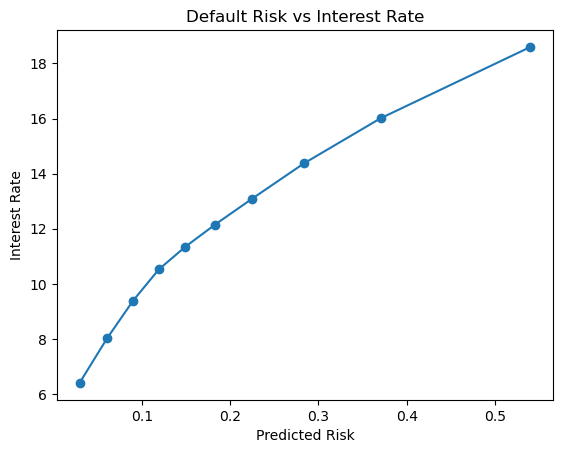

In [83]:
plt.plot(risk_pricing["default_risk"], risk_pricing["int_rate"],  marker='o')
plt.title("Default Risk vs Interest Rate")
plt.xlabel("Predicted Risk")
plt.ylabel("Interest Rate")
plt.show()

**High-risk borrowers are undercharged.**  
In the upper deciles, predicted default risk rises 
steeply but interest rates flatten out. The lender 
is taking on significantly more risk per additional 
decile without collecting a proportionally higher 
rate to compensate for it. At the extreme end, 
the gap between the risk being absorbed and the 
return being earned is at its widest — meaning 
the most dangerous loans in the portfolio are 
also the most mispriced.

**Low-risk borrowers are overcharged.**  
Even at the lowest risk deciles, interest rates 
start relatively high. The safest borrowers — 
those the model assigns a very low default 
probability — are paying more than their 
risk profile justifies. In effect, the margin 
collected from low-risk borrowers is partially 
offsetting the losses generated by underpriced 
high-risk loans. The low-risk segment is 
subsidising the high-risk one.

**The implication for the lender is twofold.**  
Underpricing high-risk borrowers erodes 
profitability and increases expected credit losses. 
Overpricing low-risk borrowers creates a 
retention problem — these are exactly the 
customers most likely to refinance elsewhere 
when offered a better rate by a competitor, 
leaving the lender with a progressively 
riskier book over time.

/var/folders/7r/bdd9kf094nn92s5vz4jlh0lw0000gp/T/ipykernel_34419/2467450977.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(


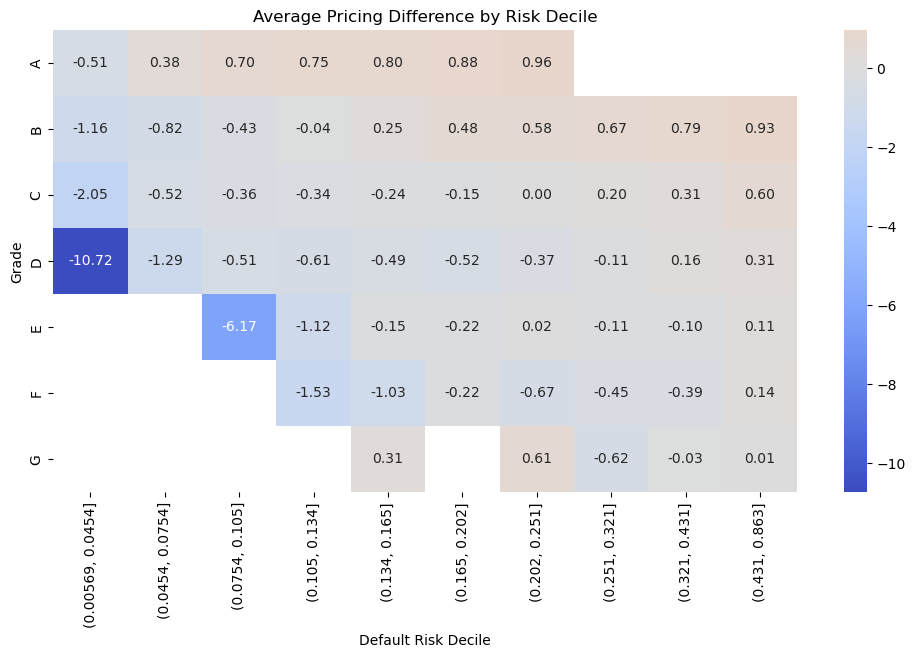

In [86]:
import seaborn as sns

# rate_min = df["int_rate"].min()
# rate_max = df["int_rate"].max()
# df["int_rate_bin_avg"] = df.groupby(["default_risk_decile", "grade"])["int_rate"].transform("mean")
# df["fair_rate"]= df["default_risk"] * (rate_max - rate_min) + rate_min

grade_avg_rate = df.groupby("grade")["int_rate"].transform("mean")
df["pricing_difference"] = df["int_rate"] - grade_avg_rate
heatmap_data = df.pivot_table(
    values="pricing_difference",
    index="grade",
    columns="default_risk_decile",
    aggfunc="mean"
)
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt=".2f", center=0,)
plt.title("Average Pricing Difference by Risk Decile")
plt.xlabel("Default Risk Decile")
plt.ylabel("Grade")
plt.show()

- Blue = underpriced relative to grade + decile
- Red = overpriced relative to grade + decile
- White (center=0) = fairly priced

**1. Introduce within-grade risk-based pricing.**  
The heatmap shows that LendingClub's pricing is driven 
almost entirely by the grade label, with minimal 
adjustment for the risk profile beneath it. Two 
borrowers in Grade C with very different predicted 
default probabilities are charged near-identical rates. 
Rates should vary within each grade band based on 
additional signals the model identifies as predictive — 
DTI, FICO subband, loan-to-income ratio, and revolving 
utilisation. This does not require replacing the 
existing grade system — it layers granular risk 
adjustment on top of it.

**2. Reprice the highest-risk deciles upward.**  
Borrowers in deciles 9 and 10 carry the steepest 
predicted default probabilities in the portfolio 
but are charged rates that do not reflect that 
expected loss. These are the loans most likely 
to generate credit losses that exceed the interest 
collected. Rate increases on this segment — or 
tighter approval criteria — would meaningfully 
reduce the lender's uncompensated risk exposure.

**3. Lower rates for the safest borrowers to 
improve retention.**  
Low-risk borrowers in deciles 1 and 2 are currently 
overcharged relative to their predicted default 
probability. These are the most creditworthy 
customers in the portfolio and the most likely 
to refinance with a competitor offering a sharper 
rate. Reducing rates modestly for this segment 
would improve retention of the best customers 
while only marginally reducing margin — 
given their low default rate, the revenue 
risk is minimal.

**4. Adopt a phased correction approach.**  
Repricing a loan book abruptly carries commercial 
risk. The recommended sequence is to lower rates 
for the lowest-risk deciles first — this improves 
retention and is commercially straightforward. 
Rate increases for high-risk segments should 
follow gradually, supported by updated 
underwriting criteria, to avoid adverse 
selection where only the highest-risk borrowers 
accept the new terms.

In [109]:
import os
print(os.getcwd())

/Users/anaistong/CFG/practice/Specialisation/Lending Club Analysis
